In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

superclass_map = {0:'vehicle', 1:'vehicle', 2:'outdoor', 3:'outdoor', 4:'animal', 5:'animal', 6:'animal', 7:'accessory', 8:'sports', 9:'sports', 10:'kitchen', 
                  11:'kitchen',12:'food', 13:'food', 14:'furniture', 15:'furniture', 16:'electronic', 17:'appliance',  18:'appliance', 19:'indoor', #end task 1 

                  20:'person', 21:'vehicle', 22:'vehicle', 23:'outdoor', 24:'animal', 25:'animal', 26:'accessory', 27:'sports', 28:'sports', 29:'kitchen',
                  30:'food',  31:'food', 32:'food',  33:'furniture', 34:'furniture', 35:'electronic', 36:'electronic', 37:'appliance',  38:'indoor', 39:'indoor', #end task 2

                  40: 'vehicle', 41: 'vehicle', 42: 'outdoor', 43: 'animal', 44: 'animal', 45: 'animal', 46: 'accessory', 47: 'sports', 48: 'sports', 49: 'sports', 50: 'kitchen',
                  51: 'kitchen', 52: 'food', 53: 'food', 54: 'kitchen', 55: 'electronic', 56: 'electronic', 57: 'appliance', 58: 'indoor', 59: 'indoor',#end task 3

                  60: 'vehicle', 61: 'vehicle', 62: 'outdoor', 63: 'animal', 64: 'animal', 65: 'accessory', 66: 'accessory', 67: 'sports', 68: 'sports', 69: 'sports', 
                  70: 'kitchen', 71: 'kitchen', 72: 'food', 73: 'food', 74: 'food', 75: 'kitchen', 76: 'electronic', 77: 'appliance', 78: 'indoor', 79: 'indoor' #end task 4
                  }

color_map = {
    "accessory":  "#1f77b4",  # blue
    "animal":     "#ff7f0e",  # orange
    "appliance":  "#2ca02c",  # green
    "electronic": "#d62728",  # red
    "food":       "#9467bd",  # purple
    "furniture":  "#8c564b",  # brown
    "indoor":     "#e377c2",  # pink
    "kitchen":    "#7f7f7f",  # gray
    "outdoor":    "#bcbd22",  # olive
    "person":     "#17becf",  # cyan
    "sports":     "#003f5c",  # dark navy
    "vehicle":    "#ff8c00",  # dark orange
    "unknown":    "#c0c0c0",  # light gray
}

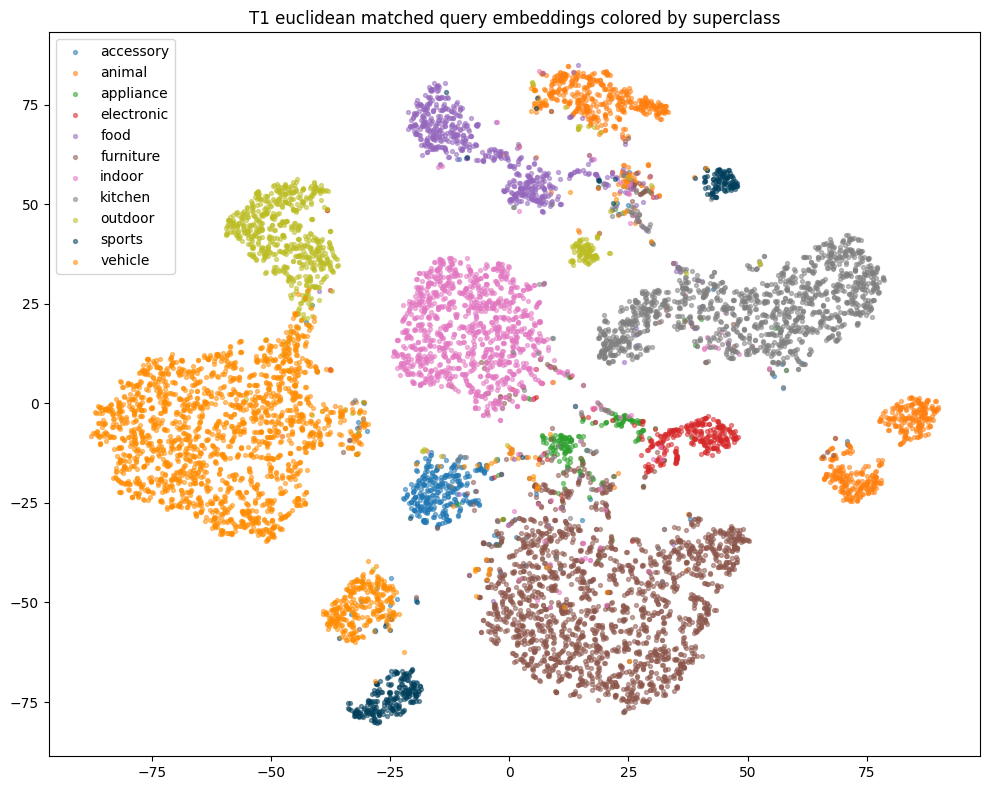

In [7]:
#********************EUCLIDEAN EMBEDDINGS************************
embeddings  = np.load('exps/eval_t1_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
labels      = np.load('exps/eval_t1_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
scores      = np.load('exps/eval_t1_hierarchical_split/euclidean/hyp_scores.npy', allow_pickle=True)
image_ids   = np.load('exps/eval_t1_hierarchical_split/euclidean/hyp_image_ids.npy', allow_pickle=True)
match_flags = np.load('exps/eval_t1_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

x = embeddings.reshape(-1, 256)
y = labels.reshape(-1)
m = match_flags.reshape(-1)

embeddings_matched = x[m]
labels_matched = y[m]

mask = labels_matched != 80 
labels_known = labels_matched[mask]
embeddings_known = embeddings_matched[mask]

embeddings_unknown = embeddings_matched[~mask]
labels_unknown = labels_matched[~mask]

sc_matched = np.array([superclass_map[int(c)] for c in labels_known])

embeddings_pca = PCA(n_components=6, random_state=42).fit_transform(embeddings_known)
Z = TSNE(init='pca', random_state=42).fit_transform(embeddings_pca)

plt.figure(figsize=(10, 8))
for sc in sorted(set(sc_matched)):
    mask = sc_matched == sc
    plt.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, color=color_map[sc], label=sc)

plt.legend()
plt.title("T1 euclidean matched query embeddings colored by superclass")
plt.tight_layout()
plt.show()

class labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 80, -1}


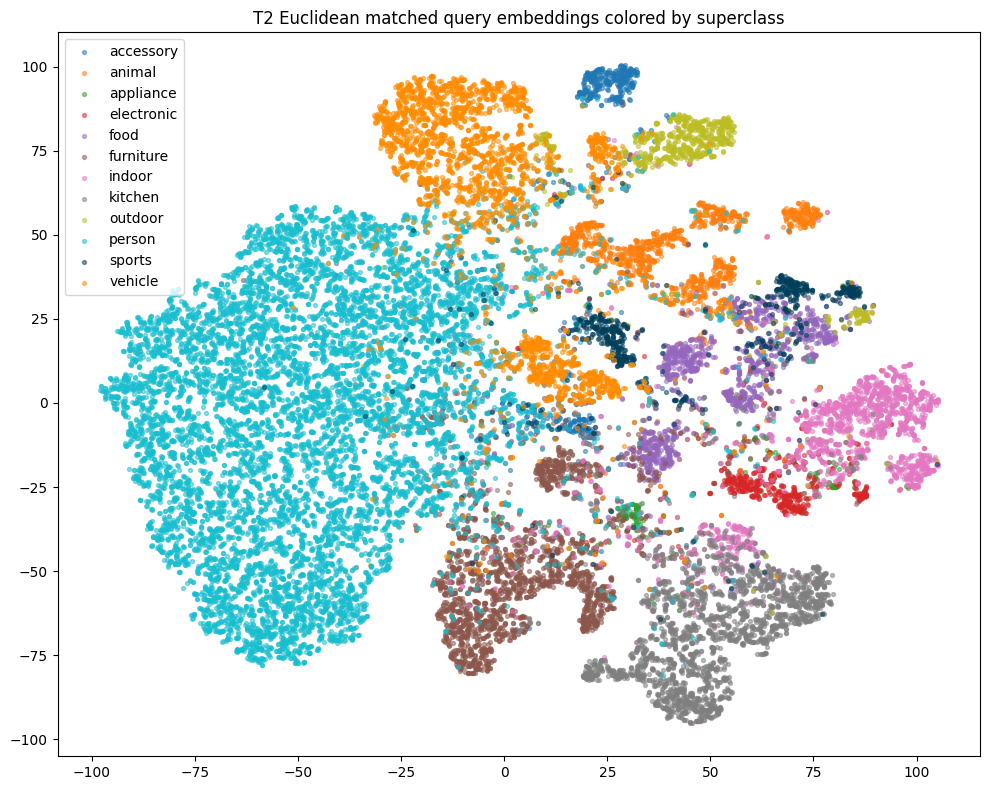

In [8]:
#********************TASK 2 EUCLIDEAN EMBEDDINGS************************
embeddings  = np.load('exps/eval_t2_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
labels      = np.load('exps/eval_t2_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
scores      = np.load('exps/eval_t2_ft_hierarchical_split/euclidean/hyp_scores.npy', allow_pickle=True)
image_ids   = np.load('exps/eval_t2_ft_hierarchical_split/euclidean/hyp_image_ids.npy', allow_pickle=True)
match_flags = np.load('exps/eval_t2_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

x = embeddings.reshape(-1, 256)
y = labels.reshape(-1)
print(f"class labels: {set(y)}")
m = match_flags.reshape(-1)

embeddings_matched = x[m]
labels_matched = y[m]

mask = labels_matched != 80 
labels_known = labels_matched[mask]
embeddings_known = embeddings_matched[mask]

embeddings_unknown = embeddings_matched[~mask]
labels_unknown = labels_matched[~mask]

sc_matched = np.array([superclass_map[int(c)] for c in labels_known])

embeddings_pca = PCA(n_components=min(6, embeddings_known.shape[1]), random_state=42).fit_transform(embeddings_known)
Z = TSNE(init='pca', random_state=42).fit_transform(embeddings_pca)

plt.figure(figsize=(10, 8))
for sc in sorted(set(sc_matched)):
    mask = sc_matched == sc
    plt.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, color=color_map[sc], label=sc)

plt.legend()
plt.title("T2 Euclidean matched query embeddings colored by superclass")
plt.tight_layout()
plt.show()

class labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 80, -1}


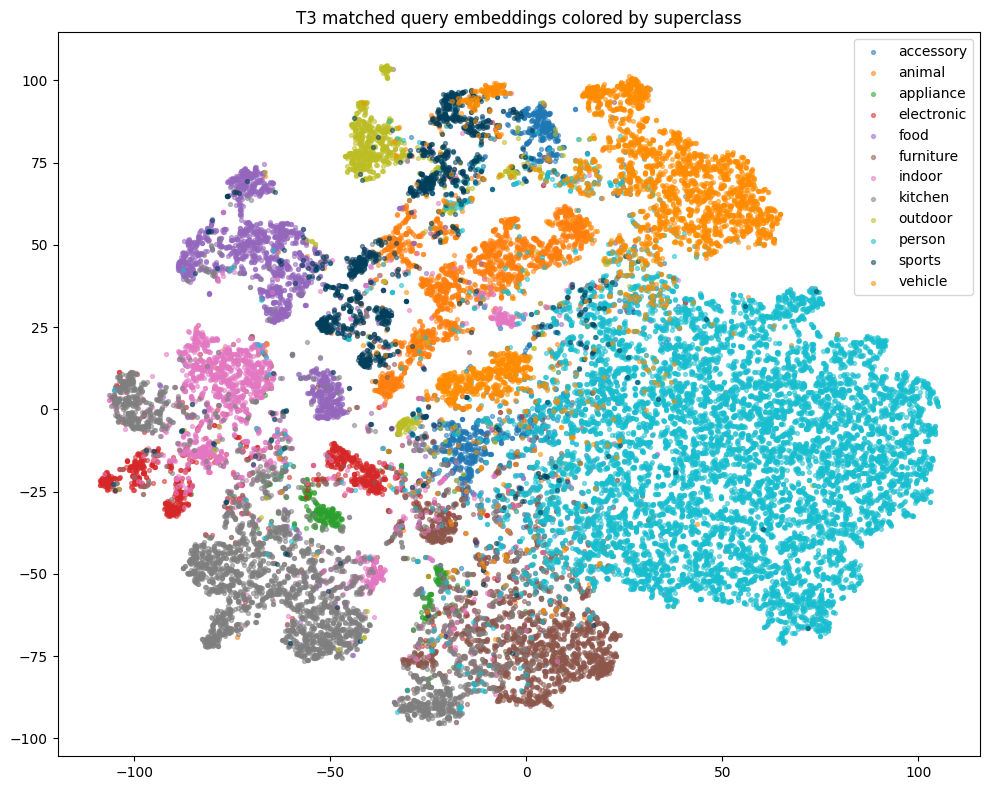

In [9]:
#********************TASK 3 EUCLIDEAN EMBEDDINGS************************
embeddings  = np.load('exps/eval_t3_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
labels      = np.load('exps/eval_t3_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
scores      = np.load('exps/eval_t3_ft_hierarchical_split/euclidean/hyp_scores.npy', allow_pickle=True)
image_ids   = np.load('exps/eval_t3_ft_hierarchical_split/euclidean/hyp_image_ids.npy', allow_pickle=True)
match_flags = np.load('exps/eval_t3_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

x = embeddings.reshape(-1, 256)
y = labels.reshape(-1)
print(f"class labels: {set(y)}")
m = match_flags.reshape(-1)

embeddings_matched = x[m]
labels_matched = y[m]

mask = labels_matched != 80 
labels_known = labels_matched[mask]
embeddings_known = embeddings_matched[mask]

embeddings_unknown = embeddings_matched[~mask]
labels_unknown = labels_matched[~mask]

sc_matched = np.array([superclass_map[int(c)] for c in labels_known])

embeddings_pca = PCA(n_components=min(6, embeddings_known.shape[1]), random_state=42).fit_transform(embeddings_known)
Z = TSNE(init='pca', random_state=42).fit_transform(embeddings_pca)

plt.figure(figsize=(10, 8))
for sc in sorted(set(sc_matched)):
    mask = sc_matched == sc
    plt.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, color=color_map[sc], label=sc)

plt.legend()
plt.title("T3 matched query embeddings colored by superclass")
plt.tight_layout()
plt.show()

class labels: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, -1}


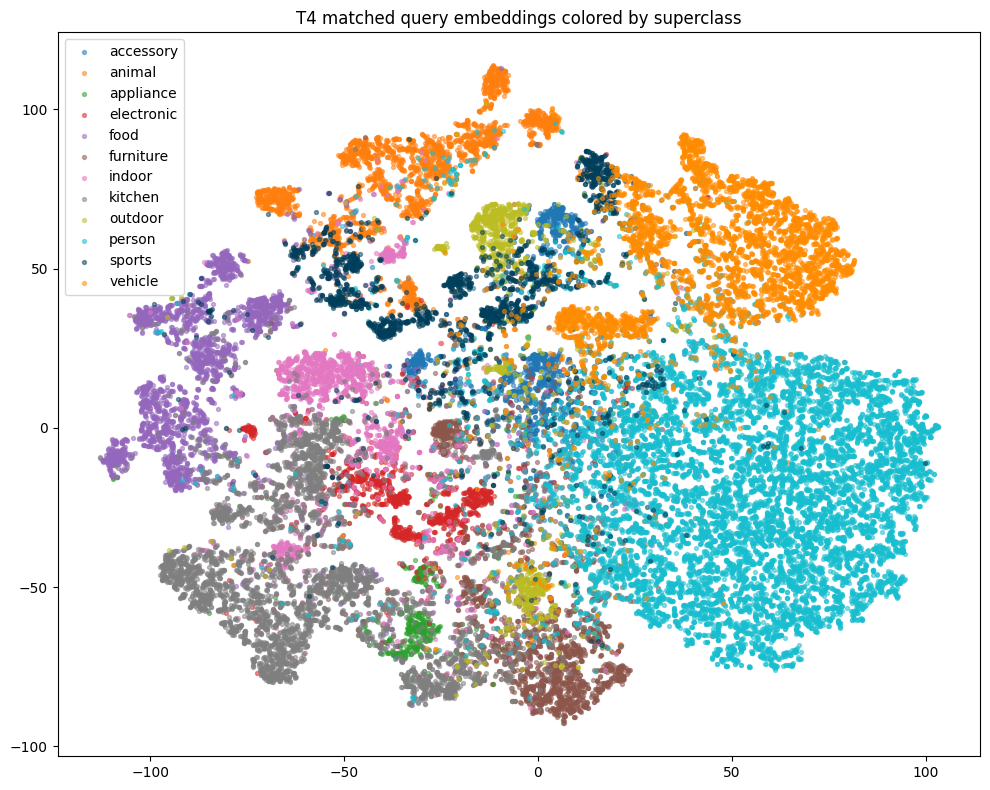

In [10]:
#********************TASK 4 EUCLIDEAN EMBEDDINGS************************
embeddings  = np.load('exps/eval_t4_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
labels      = np.load('exps/eval_t4_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
scores      = np.load('exps/eval_t4_ft_hierarchical_split/euclidean/hyp_scores.npy', allow_pickle=True)
image_ids   = np.load('exps/eval_t4_ft_hierarchical_split/euclidean/hyp_image_ids.npy', allow_pickle=True)
match_flags = np.load('exps/eval_t4_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

x = embeddings.reshape(-1, 256)
y = labels.reshape(-1)
print(f"class labels: {set(y)}")
m = match_flags.reshape(-1)

embeddings_matched = x[m]
labels_matched = y[m]

mask = labels_matched != 80 
labels_known = labels_matched[mask]
embeddings_known = embeddings_matched[mask]

embeddings_unknown = embeddings_matched[~mask]
labels_unknown = labels_matched[~mask]

sc_matched = np.array([superclass_map[int(c)] for c in labels_known])

embeddings_pca = PCA(n_components=min(6, embeddings_known.shape[1]), random_state=42).fit_transform(embeddings_known)
Z = TSNE(init='pca', random_state=42).fit_transform(embeddings_pca)

plt.figure(figsize=(10, 8))
for sc in sorted(set(sc_matched)):
    mask = sc_matched == sc
    plt.scatter(Z[mask, 0], Z[mask, 1], s=8, alpha=0.5, color=color_map[sc], label=sc)

plt.legend()
plt.title("T4 matched query embeddings colored by superclass")
plt.tight_layout()
plt.show()

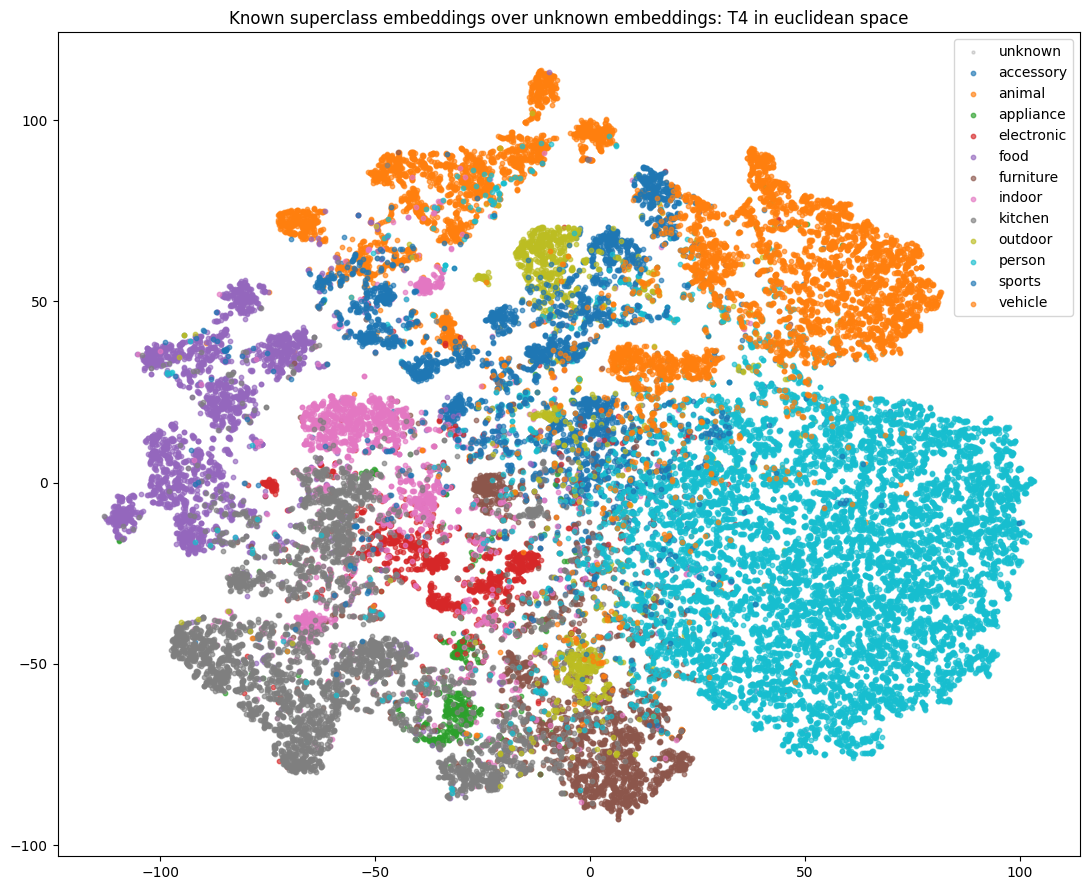

In [12]:
embeddings  = np.load('exps/eval_t4_ft_hierarchical_split/euclidean/hyp_embeddings.npy', allow_pickle=True)
labels      = np.load('exps/eval_t4_ft_hierarchical_split/euclidean/hyp_labels.npy', allow_pickle=True)
scores      = np.load('exps/eval_t4_ft_hierarchical_split/euclidean/hyp_scores.npy', allow_pickle=True)
image_ids   = np.load('exps/eval_t4_ft_hierarchical_split/euclidean/hyp_image_ids.npy', allow_pickle=True)
match_flags = np.load('exps/eval_t4_ft_hierarchical_split/euclidean/hyp_match_flags.npy', allow_pickle=True)

x = embeddings.reshape(-1, 256)
y = labels.reshape(-1)
m = match_flags.reshape(-1)

embeddings_matched = x[m]
labels_matched = y[m]

mask = labels_matched != 80 
labels_known = labels_matched[mask]
embeddings_known = embeddings_matched[mask]

embeddings_unknown = embeddings_matched[~mask]
labels_unknown = labels_matched[~mask]

sc_matched = np.array([superclass_map[int(c)] for c in labels_known])
X_combined = np.vstack([embeddings_unknown, embeddings_known])

X_pca = PCA(n_components=min(6, X_combined.shape[1]),random_state=42).fit_transform(X_combined)

Z_combined = TSNE(init='pca', random_state=42).fit_transform(X_pca)

n_unknown = len(embeddings_unknown)
Z_unknown = Z_combined[:n_unknown]
Z_known = Z_combined[n_unknown:]

plt.figure(figsize=(11, 9))

plt.scatter(Z_unknown[:, 0], Z_unknown[:, 1], s=5, alpha=0.12, c='k', label='unknown')

for sc in sorted(set(sc_matched)):
    mask = sc_matched == sc
    plt.scatter(Z_known[mask, 0], Z_known[mask, 1], s=10, alpha=0.65, label=sc)

plt.legend()
plt.title("Known superclass embeddings over unknown embeddings: T4 in euclidean space")
plt.tight_layout()
plt.show()